In [1]:
import pandas as pd

In [6]:
dfs = []

folders = [
    'UltraFast_2x10_1x5_Dynamic/20251216-182246'
]

for folder in folders:
    df = pd.read_csv(f'{folder}/summary.txt')
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df

,dataset,algorithm,hybrid_accuracy_train,hybrid_reject_train,hybrid_kappa_train,hybrid_accuracy_test,hybrid_reject_test,hybrid_kappa_test
0,174,1x5_Dynamic_Binary_Shallow,0.999432,0.000000,0.029944,0.912763,0.000000,0.167621
1,19,1x5_Dynamic_Binary_Shallow,0.996399,0.000000,0.442204,0.988422,0.000000,0.442556
2,212,1x5_Dynamic_Binary_Shallow,0.983692,0.000000,0.212109,0.830645,0.000000,0.293160
3,43,1x5_Dynamic_Binary_Shallow,0.775777,0.000000,0.253359,0.745054,0.000000,0.226727
4,451,1x5_Dynamic_Binary_Shallow,0.917633,0.000000,0.056105,0.768182,0.000000,0.107217
5,52,1x5_Dynamic_Binary_Shallow,0.966921,0.000000,0.357349,0.921627,0.000000,0.231279
6,174,1x5_Dynamic_Double_AR_Shallow,0.999603,0.247864,0.028361,0.939120,0.279342,0.172208
7,19,1x5_Dynamic_Double_AR_Shallow,0.998266,0.140785,0.298933,0.997651,0.150173,0.310798
8,212,1x5_Dynamic_Double_AR_Shallow,0.998515,0.389427,0.144077,0.933198,0.398387,0.256200
9,43,1x5_Dynamic_Double_AR_Shallow,0.840610,0.265614,0.180262,0.809843,0.261505,0.154903


In [7]:
df['algorithm'].unique()

array(['1x5_Dynamic_Binary_Shallow', '1x5_Dynamic_Double_AR_Shallow',
       '1x5_Dynamic_Double_GB_Shallow', '1x5_Dynamic_Ternary_Shallow',
       '1x5_Dynamic_Binary_Deep', '1x5_Dynamic_Double_AR_Deep',
       '1x5_Dynamic_Double_GB_Deep', '1x5_Dynamic_Ternary_Deep'],
      dtype=object)

In [9]:
# 1) Per-dataset ranks (best rank = 1)
#    - Higher is better: accuracy, kappa
#    - Lower is better:  reject rate

rank_specs = {
    'hybrid_accuracy_test': 'max',
    'hybrid_reject_test': 'max',
    'hybrid_kappa_test': 'min',
}

for metric, best in rank_specs.items():
    ascending = (best == 'min')   # True if lower=better
    df[f'{metric}_rank'] = df.groupby('dataset')[metric].rank(
        ascending=ascending, method='average'
    )

df.head()

,dataset,algorithm,hybrid_accuracy_train,hybrid_reject_train,hybrid_kappa_train,hybrid_accuracy_test,hybrid_reject_test,hybrid_kappa_test,hybrid_accuracy_test_rank,hybrid_reject_test_rank,hybrid_kappa_test_rank
0,174,1x5_Dynamic_Binary_Shallow,0.999432,0.0,0.029944,0.912763,0.0,0.167621,7.0,7.5,2.0
1,19,1x5_Dynamic_Binary_Shallow,0.996399,0.0,0.442204,0.988422,0.0,0.442556,5.0,7.5,4.0
2,212,1x5_Dynamic_Binary_Shallow,0.983692,0.0,0.212109,0.830645,0.0,0.293160,7.0,7.5,4.0
3,43,1x5_Dynamic_Binary_Shallow,0.775777,0.0,0.253359,0.745054,0.0,0.226727,7.0,7.5,8.0
4,451,1x5_Dynamic_Binary_Shallow,0.917633,0.0,0.056105,0.768182,0.0,0.107217,2.5,7.5,8.0


In [11]:
# 2) Summary by algorithm across datasets
summary = (
    df.groupby('algorithm')
      .agg(
          mean_test_acc=('hybrid_accuracy_test', 'mean'),
          mean_test_kappa=('hybrid_kappa_test', 'mean'),
          mean_test_reject=('hybrid_reject_test', 'mean'),
          acc_rank_mean=('hybrid_accuracy_test_rank', 'mean'),
          kappa_rank_mean=('hybrid_kappa_test_rank', 'mean'),
          reject_rank_mean=('hybrid_reject_test_rank', 'mean'),
      )
      .reset_index()
)

summary.head()

,algorithm,mean_test_acc,mean_test_kappa,mean_test_reject,acc_rank_mean,kappa_rank_mean,reject_rank_mean
0,1x5_Dynamic_Binary_Deep,0.858691,0.290855,0.000000,6.666667,6.333333,7.500000
1,1x5_Dynamic_Binary_Shallow,0.861116,0.244760,0.000000,5.833333,5.500000,7.500000
2,1x5_Dynamic_Double_AR_Deep,0.885172,0.223401,0.276512,3.500000,4.500000,2.833333
3,1x5_Dynamic_Double_AR_Shallow,0.902767,0.180470,0.326978,1.666667,3.666667,1.333333
4,1x5_Dynamic_Double_GB_Deep,0.878431,0.249036,0.192968,4.666667,5.166667,5.333333


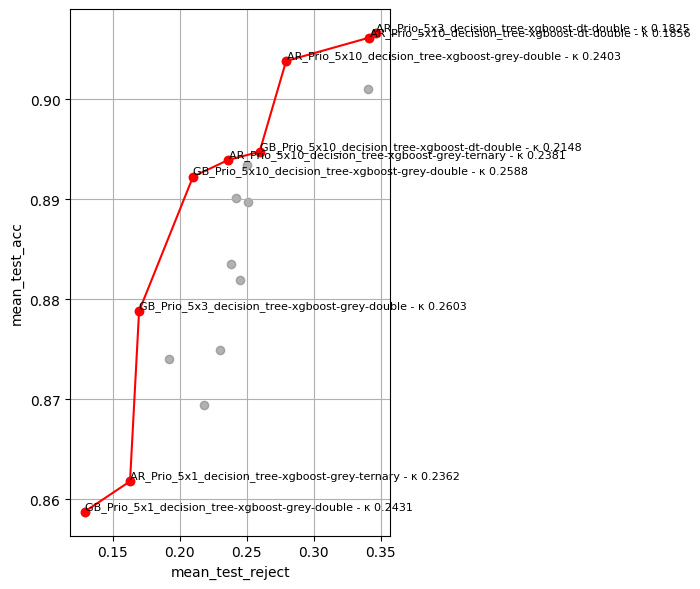

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

dfp = summary.copy()

# --- Compute Pareto frontier ---
def pareto_frontier(df, x_col, y_col, maximize_x=False, maximize_y=True):
    # Sort by x (descending if maximize_x)
    df_sorted = df.sort_values(by=x_col, ascending=not maximize_x)
    pareto = []
    best_y = -np.inf if maximize_y else np.inf

    for _, row in df_sorted.iterrows():
        y = row[y_col]
        if maximize_y and y > best_y or not maximize_y and y < best_y:
            pareto.append(row)
            best_y = y
    return pd.DataFrame(pareto)

x_col, should_maximize_x = 'mean_test_reject', False
y_col, should_maximize_y = 'mean_test_acc', True

frontier = pareto_frontier(dfp, x_col, y_col, should_maximize_x, should_maximize_y)

# --- Plot ---
plt.figure(figsize=(7,6))
plt.scatter(dfp[x_col], dfp[y_col], c='gray', alpha=0.6, label='All algorithms')
plt.plot(frontier[x_col], frontier[y_col], 'r-o', label='Pareto frontier')

# Label points
for _, row in frontier.iterrows():
    plt.text(row[x_col]+0.0003, row[y_col]+0.0003, f'{row['algorithm']} - κ {row['mean_test_kappa']:.4f}', fontsize=8)

plt.xlabel(x_col)
plt.ylabel(y_col)
#plt.title('Pareto Frontier: Accuracy vs. Grader Consistency')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
df_new = pd.read_csv('./summary_new.txt')
df_new.head()

,dataset,algorithm,train_acc_mean,train_reject_mean,train_grader_kappa_mean,test_acc_mean,test_reject_mean,test_grader_kappa_mean
0,bench,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.985331,0.299484,0.049914,0.819193,0.346032,0.106731
1,brst-w,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.998873,0.233744,0.078540,0.978440,0.245437,0.162553
2,blood,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.896376,0.432122,0.191920,0.869089,0.437544,0.158146
3,car,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.996538,0.109589,0.291588,0.991905,0.125204,0.277644
4,vertebr,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.994685,0.349343,0.152675,0.906499,0.347312,0.224264


In [9]:
df_new['algorithm'].unique()

array(['AR_Prio_5x1_decision_tree-xgboost-dt-double',
       'AR_Prio_5x1_decision_tree-xgboost-dt-ternary',
       'AR_Prio_5x1_decision_tree-xgboost-grey-double',
       'AR_Prio_5x1_decision_tree-xgboost-grey-ternary',
       'AR_Prio_5x3_decision_tree-xgboost-dt-double',
       'AR_Prio_5x3_decision_tree-xgboost-dt-ternary',
       'AR_Prio_5x3_decision_tree-xgboost-grey-double',
       'AR_Prio_5x3_decision_tree-xgboost-grey-ternary',
       'AR_Prio_5x10_decision_tree-xgboost-dt-double',
       'AR_Prio_5x10_decision_tree-xgboost-dt-ternary',
       'AR_Prio_5x10_decision_tree-xgboost-grey-double',
       'AR_Prio_5x10_decision_tree-xgboost-grey-ternary',
       'GB_Prio_5x1_decision_tree-xgboost-dt-double',
       'GB_Prio_5x1_decision_tree-xgboost-grey-double',
       'GB_Prio_5x3_decision_tree-xgboost-dt-double',
       'GB_Prio_5x3_decision_tree-xgboost-grey-double',
       'GB_Prio_5x10_decision_tree-xgboost-dt-double',
       'GB_Prio_5x10_decision_tree-xgboost-grey-double'

In [10]:
# 1) Per-dataset ranks (best rank = 1)
#    - Higher is better: accuracy, kappa
#    - Lower is better:  reject rate

rank_specs = {
    'test_acc_mean': 'max',
    'test_grader_kappa_mean': 'max',
    'test_reject_mean': 'min',
}

for metric, best in rank_specs.items():
    ascending = (best == 'min')   # True if lower=better
    df_new[f'{metric}_rank'] = df_new.groupby('dataset')[metric].rank(
        ascending=ascending, method='average'
    )

df_new.head()

,dataset,algorithm,train_acc_mean,train_reject_mean,train_grader_kappa_mean,test_acc_mean,test_reject_mean,test_grader_kappa_mean,test_acc_mean_rank,test_grader_kappa_mean_rank,test_reject_mean_rank
0,bench,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.985331,0.299484,0.049914,0.819193,0.346032,0.106731,19.0,8.0,13.0
1,brst-w,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.998873,0.233744,0.078540,0.978440,0.245437,0.162553,5.0,30.0,29.0
2,blood,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.896376,0.432122,0.191920,0.869089,0.437544,0.158146,1.0,12.0,30.0
3,car,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.996538,0.109589,0.291588,0.991905,0.125204,0.277644,12.0,29.0,21.0
4,vertebr,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.994685,0.349343,0.152675,0.906499,0.347312,0.224264,12.0,30.0,25.0


In [11]:
# 2) Summary by algorithm across datasets
summary_new = (
    df_new.groupby('algorithm')
      .agg(
          mean_test_acc=('test_acc_mean', 'mean'),
          std_test_acc=('test_acc_mean', 'std'),
          mean_test_kappa=('test_grader_kappa_mean', 'mean'),
          std_test_kappa=('test_grader_kappa_mean', 'std'),
          mean_test_reject=('test_reject_mean', 'mean'),
          std_test_reject=('test_reject_mean', 'std'),
          acc_rank_mean=('test_acc_mean_rank', 'mean'),
          kappa_rank_mean=('test_grader_kappa_mean_rank', 'mean'),
          reject_rank_mean=('test_reject_mean_rank', 'mean'),
      )
      .reset_index()
)

summary_new.head()

,algorithm,mean_test_acc,std_test_acc,mean_test_kappa,std_test_kappa,mean_test_reject,std_test_reject,acc_rank_mean,kappa_rank_mean,reject_rank_mean
0,AR_Prio_5x10_decision_tree-xgboost-dt-double,0.906150,0.088898,0.185625,0.090164,0.341563,0.140707,4.3,18.4,27.30
1,AR_Prio_5x10_decision_tree-xgboost-dt-ternary,0.890108,0.080333,0.194055,0.081956,0.241898,0.089894,15.1,18.1,15.95
2,AR_Prio_5x10_decision_tree-xgboost-grey-double,0.903811,0.077641,0.240291,0.174802,0.279489,0.158460,8.8,13.8,21.70
3,AR_Prio_5x10_decision_tree-xgboost-grey-ternary,0.893919,0.074173,0.238108,0.178082,0.236277,0.138974,17.6,15.4,14.60
4,AR_Prio_5x1_decision_tree-xgboost-dt-double,0.900981,0.086065,0.168493,0.089196,0.340590,0.130231,8.5,23.0,25.70


In [12]:
# 3) If you want a single "overall" rank (give more weight to ranks)
#    Example: weight ranks 70%, raw metrics 30% (normalized to [0,1] per metric)
#    (Optional—tune weights/metrics to your needs)
def minmax(col):
    c = col.astype(float)
    rng = c.max() - c.min()
    return (c - c.min()) / rng if rng else pd.Series([0.5]*len(c), index=c.index)

tmp = summary_new.copy()
tmp['acc_norm']   = minmax(tmp['mean_test_acc'])
tmp['kappa_norm'] = minmax(tmp['mean_test_kappa'])
tmp['reject_norm']= 1 - minmax(tmp['mean_test_reject'])  # lower reject is better → invert

# Rank parts: lower avg rank is better → convert to [0,1] where 1 is best
for rcol in ['acc_rank_mean','kappa_rank_mean','reject_rank_mean']:
    tmp[f'{rcol}_norm'] = 1 - minmax(tmp[rcol])

summary_new['hybrid_score'] = (
    0.7 * (tmp['acc_rank_mean_norm'] + tmp['kappa_rank_mean_norm'] + tmp['reject_rank_mean_norm'])/3
  + 0.3 * (tmp['acc_norm'] + tmp['kappa_norm'] + tmp['reject_norm'])/3
)

summary_new.sort_values('hybrid_score', ascending=False)

,algorithm,mean_test_acc,std_test_acc,mean_test_kappa,std_test_kappa,mean_test_reject,std_test_reject,acc_rank_mean,kappa_rank_mean,reject_rank_mean,hybrid_score
28,GB_Prio_5xInf5_decision_tree-xgboost-grey-double,0.887172,0.084570,0.261527,0.190349,0.198538,0.106696,18.3,8.5,7.20,0.747128
13,GB_Prio_5x10_decision_tree-xgboost-grey-double,0.892258,0.079592,0.258784,0.192722,0.210068,0.120170,16.5,9.1,8.45,0.746636
24,GB_Prio_5xInf15_decision_tree-xgboost-grey-double,0.902754,0.070105,0.262733,0.177924,0.236770,0.144830,12.9,9.5,13.55,0.743009
18,GB_Prio_5x25_decision_tree-xgboost-grey-double,0.896554,0.077551,0.256203,0.178181,0.241226,0.146975,13.2,9.9,14.15,0.707478
21,GB_Prio_5x3_decision_tree-xgboost-grey-double,0.878802,0.086755,0.260326,0.214226,0.169766,0.096514,23.2,11.0,3.50,0.691614
12,GB_Prio_5x10_decision_tree-xgboost-dt-double,0.894732,0.086229,0.214783,0.089943,0.259661,0.086427,9.3,11.4,16.65,0.645985
2,AR_Prio_5x10_decision_tree-xgboost-grey-double,0.903811,0.077641,0.240291,0.174802,0.279489,0.158460,8.8,13.8,21.70,0.606099
10,AR_Prio_5x3_decision_tree-xgboost-grey-double,0.893384,0.080127,0.248824,0.191081,0.250516,0.146892,15.0,12.9,16.80,0.604759
16,GB_Prio_5x25_decision_tree-xgboost-dt-double,0.896941,0.081892,0.213492,0.100529,0.280130,0.100853,10.0,11.6,21.00,0.592094
25,GB_Prio_5xInf15_decision_tree-xgboost-grey-ter...,0.897931,0.073529,0.245871,0.158390,0.254167,0.145960,13.8,14.1,18.15,0.591217


AR_Prio_5x10_decision_tree-xgboost-dt-double
AR_Prio_5x10_decision_tree-xgboost-dt-ternary
AR_Prio_5x1_decision_tree-xgboost-dt-double
AR_Prio_5x1_decision_tree-xgboost-dt-ternary
AR_Prio_5x3_decision_tree-xgboost-dt-double
AR_Prio_5x3_decision_tree-xgboost-dt-ternary
GB_Prio_5x10_decision_tree-xgboost-dt-double
GB_Prio_5x1_decision_tree-xgboost-dt-double
GB_Prio_5x25_decision_tree-xgboost-dt-double
GB_Prio_5x25_decision_tree-xgboost-dt-ternary
GB_Prio_5x3_decision_tree-xgboost-dt-double
GB_Prio_5xInf15_decision_tree-xgboost-dt-double
GB_Prio_5xInf15_decision_tree-xgboost-dt-ternary
GB_Prio_5xInf5_decision_tree-xgboost-dt-double
GB_Prio_5xInf5_decision_tree-xgboost-dt-ternary


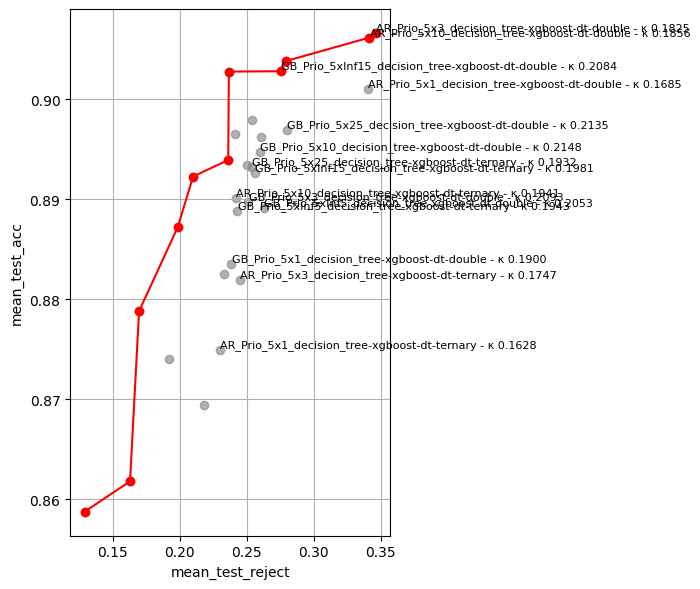

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Example: use the summary table we already built
# columns: ['algorithm', 'mean_test_acc', 'mean_test_kappa']
dfp = summary_new.copy()

# --- Compute Pareto frontier ---
def pareto_frontier(df, x_col, y_col, maximize_x=False, maximize_y=True):
    # Sort by x (descending if maximize_x)
    df_sorted = df.sort_values(by=x_col, ascending=not maximize_x)
    pareto = []
    best_y = -np.inf if maximize_y else np.inf

    for _, row in df_sorted.iterrows():
        y = row[y_col]
        if maximize_y and y > best_y or not maximize_y and y < best_y:
            pareto.append(row)
            best_y = y
    return pd.DataFrame(pareto)

x_col, should_maximize_x = 'mean_test_reject', False
y_col, should_maximize_y = 'mean_test_acc', True

frontier = pareto_frontier(dfp, x_col, y_col, should_maximize_x, should_maximize_y)

# --- Plot ---
plt.figure(figsize=(7,6))
plt.scatter(dfp[x_col], dfp[y_col], c='gray', alpha=0.6, label='All algorithms')
plt.plot(frontier[x_col], frontier[y_col], 'r-o', label='Pareto frontier')

# Label points
show_label = [
    # "GB_Prio_5x10_decision_tree-xgboost-dt-double",
    "GB_Prio_5xInf5_decision_tree-xgboost-dt-double",
    "AR_Prio_5xInf5_decision_tree-xgboost-dt-double",
    # "GB_Prio_5x10_decision_tree-xgboost-grey-double",
    # "GB_Prio_5xInf5_decision_tree-xgboost-grey-double",
    # "AR_Prio_5xInf5_decision_tree-xgboost-grey-double",
    # "GB_Prio_5x10_decision_tree-xgboost-grey-double",
    # "GB_Prio_5xInf15_decision_tree-xgboost-grey-double",
    # "GB_Prio_5x25_decision_tree-xgboost-grey-double",
    # "GB_Prio_5x3_decision_tree-xgboost-grey-double",
    # "GB_Prio_5x10_decision_tree-xgboost-dt-double",
    # "AR_Prio_5x1_decision_tree-xgboost-dt-ternary",
    "GB_Prio_5xInf5_decision_tree-xgboost-grey-ternary",
    # "GB_Prio_5xInf5_decision_tree-xgboost-dt-ternary",
]
for _, row in dfp.iterrows():
    if 'dt' in row['algorithm']:
        plt.text(row[x_col]+0.0003, row[y_col]+0.0003, f'{row['algorithm']} - κ {row['mean_test_kappa']:.4f}', fontsize=8)
        print(row['algorithm'])

plt.xlabel(x_col)
plt.ylabel(y_col)
#plt.title('Pareto Frontier: Accuracy vs. Grader Consistency')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
